# **AI Agent 도구와 메모리**

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `ai_agent`를 생성(이미 만들었다면 skip)
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (2) 라이브러리

* 필요한 라이브러리 설치

In [ ]:
!pip install langchain-openai langchain_community -q

* 라이브러리 로딩

In [ ]:
import pandas as pd
import numpy as np
import os
import openai

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END

### (3) OpenAI API Key 확인

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "="     in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/ai_agent/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

* ⚠️ api_key가 잘 등록되었는지 확인

In [ ]:
print(os.environ['OPENAI_API_KEY'][:40])

## **2. 도구 사용하기**

### **(1) 단순 Agent**
영화 추천 에이전트

In [ ]:
class SimpleState(MessagesState):
    response: str

In [ ]:
llm = ChatOpenAI(model = "gpt-4.1-mini")

* **노드 준비**

In [ ]:
def chatbot(state: SimpleState):
    # 1. State에서 필요한 정보 저장
    prompt = state["messages"][0].content

    # 2. prompt 구성
    sys_msg = SystemMessage('''
    # 역할
    너는 영화 추천 전문가야.

    # 지침
    사용자의 입력을 고려하여 영화 2편을 추천해줘
    ''')

    hu_msg = HumanMessage(prompt)

    # 3. llm 호출
    result = llm.invoke([sys_msg, hu_msg])

    # 4. state 업데이트
    return {"messages": result, "response": result.content}

* **그래프 구성**

In [ ]:
# 그래프 초기화
builder = StateGraph(SimpleState)

# 노드 추가
builder.add_node("chatbot", chatbot)

# 엣지 추가
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# 컴파일
graph = builder.compile()

In [ ]:
graph

* **Graph 실행**


In [ ]:
# 초기 state 준비
initial_state = {"messages": "오늘은 달달한 로맨틱 코미디"}

# 그래프 실행
result = graph.invoke(initial_state)

* 결과 열어보기

In [ ]:
# messages에 쌓인 내용을 순차적으로 출력하기
for m in result["messages"]:
    m.pretty_print()

* 최근 영화 추천 요청

In [ ]:
# 초기 state 준비
initial_state = {"messages": "오늘은 달달한 로맨틱 코미디, 2026년 영화"}

# 그래프 실행
result = graph.invoke(initial_state)

In [ ]:
# messages에 쌓인 내용을 순차적으로 출력하기
for m in result["messages"]:
    m.pretty_print()

### **(2) 도구① : 기존 도구 사용하기**
* 검색 도구 추가

In [ ]:
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

#### **1) 도구 준비**

* 라이브러리 설치 및 api key 설정

In [ ]:
!pip install -q langchain-tavily tavily-python

In [ ]:
# API 키 로드 및 환경변수 설정 및 확인
load_api_keys(path + 'api_key.txt')
print(os.environ['TAVILY_API_KEY'][:30])

* Tool 준비하기

In [ ]:
from langchain_tavily import TavilySearch

# Tavily 도구 준비
# max_results: 검색 결과 개수 제한
tavily_tool = TavilySearch(max_results=3)

* 검색 도구 TavilySearch 사용해보기
    * 검색 함수 사용 : **.invoke({"query": "검색할 내용"})**

In [ ]:
# 검색도구 사용해보기
result = tavily_tool.invoke({"query": "AI Agent"})

In [ ]:
result

#### **2) 도구 사용 Agent**

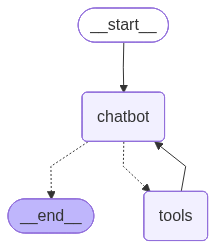

In [ ]:
from langgraph.graph import MessagesState

class SimpleState(MessagesState):
    response: str

In [ ]:
llm = ChatAnthropic(model="claude-sonnet-4-6").bind_tools([tavily_tool])

* **노드 준비**

In [ ]:
def chatbot(state: SimpleState):
    # 1. State에서 필요한 정보 저장

    # 2. prompt 구성
    sys_msg = SystemMessage('''
    # 역할
    너는 영화 추천 전문가야.

    # 지침
    - 사용자의 입력을 고려하여 영화 2편을 추천해줘
    - 최신 영화 정보가 필요하면 검색 도구(tavily_tool)를 활용해.
    - 영화 추천시 너가 지어내면 안돼.
    ''')

    # 3. llm 호출
    result = llm.invoke([sys_msg] + state["messages"])

    # 4. state 업데이트
    return {"messages": result, "response": result.content}

* **ToolNode, tools_condition 준비**

In [ ]:
from langgraph.prebuilt import ToolNode, tools_condition

# 도구 노드 준비
tool_node = ToolNode([tavily_tool])

* **그래프 구성**

In [ ]:
# 그래프 초기화
builder = StateGraph(SimpleState)

# 노드 추가
builder.add_node("chatbot", chatbot)
builder.add_node("tools", tool_node)        # 도구 실행 노드 추가

# 엣지 추가
builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition,
                              {'tools': 'tools', '__end__': END})
builder.add_edge("tools", "chatbot")        # 도구 실행 후 다시 chatbot으로

# 컴파일
graph = builder.compile()

In [ ]:
graph

* 최근 영화 추천 요청

In [ ]:
# 초기 state 준비
initial_state : SimpleState= {"messages": "오늘은 달달한 로맨틱 코미디, 2026년 영화"}

# 그래프 실행
result = graph.invoke(initial_state)

In [ ]:
# messages에 쌓인 내용을 순차적으로 출력하기
for m in result["messages"]:
    m.pretty_print()

In [ ]:
result

### **(3) 도구② : 도구 만들어 사용하기**

#### **1) 도구 준비**

* 직접 도구를 만들때 세 가지를 기억하세요.
    * 도구를 **함수**로 구현
    * 함수 선언시, 바로 윗 줄에 **@tool** 데코레이터 추가
    * 함수 선언(def 라인) 바로 아래로 **docstring** 추가 : 함수에 대한 설명

In [ ]:
@tool
def calculator_tool(expression: str) -> str:  # type hint : 함수의 출력 type은 str
    '''수식을 입력 받아 계산하는 도구'''
    result = eval(expression)  # Python 내장 함수 eval()을 사용해서 문자열로 된 식을 계산
    return f"계산 결과: {result}"

@tool
def get_weather(location: str):
    """현재 날씨 정보를 반환합니다."""
    # 입력된 지역이 "서울"인 경우에 해당하는 날씨 정보를 반환합니다.
    if location in ["서울"]:
        return "현재 온도는 20도이며 맑고 화창한 날씨입니다."
    else:
        # "서울"이 아닌 경우, 다른 날씨 정보를 반환합니다.
        return "현재 온도는 10도이며 조금 쌀쌀합니다."


* **ToolNode**

In [ ]:
tools = [get_weather, calculator_tool]
tool_node = ToolNode(tools)

* **ToolNode를 직접 사용하는 것도 가능**

In [ ]:
llm_tools.invoke("서울 날씨는 어때?").tool_calls

In [ ]:
llm_tools.invoke("오늘 점심은 뭐 먹을까?").tool_calls

In [ ]:
llm_tools.invoke("1+3*(20-15)").tool_calls

#### **2) 도구 사용 Agent**


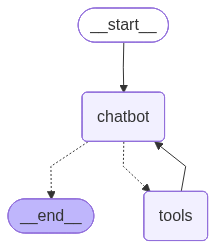

* State

In [ ]:
class SimpleState(MessagesState):
    response: str

In [ ]:
llm_tools = ChatAnthropic(model="claude-sonnet-4-6").bind_tools(tools)

* Node

In [ ]:
def chatbot(state: SimpleState):
    # 1. State에서 필요한 정보 저장
    messages = state["messages"]

    # 2. prompt 구성

    # 3. llm 호출
    result = llm_tools.invoke(messages)

    # 4. state 업데이트
    return {"messages": result, "response": result.content}

* 그래프 구성

In [ ]:
# 그래프 초기화
builder = StateGraph(SimpleState)

# 노드 추가
builder.add_node("chatbot", chatbot)
builder.add_node("tools", tool_node)        # 도구 실행 노드 추가

# 엣지 추가
builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)                         # tool_use면 tools로, 아니면 END로
builder.add_edge("tools", "chatbot")        # 도구 실행 후 다시 chatbot으로

# 컴파일
graph = builder.compile()

* 그래프 시각화

In [ ]:
graph

* 그래프 사용하기

In [ ]:
# 초기 state 준비
initial_state = {"messages": "오늘 서울 날씨는?"}

# 그래프 실행
result = graph.invoke(initial_state)

for m in result["messages"]:
    m.pretty_print()

In [ ]:
# 초기 state 준비
initial_state = {"messages": "2**8"}

# 그래프 실행
result = graph.invoke(initial_state)

for m in result["messages"]:
    m.pretty_print()

### **(4) 실습🔥**

* 기존 Agent를 수정해 봅시다.
    * 날씨 도구 교체하기 :
        * 아래 함수를 이용해서 날씨 도구를 교체하세요.
        * 교체시 도구로써 필요한 장치-데코레이터, docstring-을 적절히 추가하세요.
    * ToolNode에 검색 도구도 추가하세요.

* 기온 가져오기 함수

In [ ]:
# 도시를 입력하면, 현재 날씨를 가져오는 함수입니다.
# 별도 api key 없이 사용 가능

import requests

def get_weather(city: str) -> str:

    # 1. 도시명 → 위경도 변환
    geo = requests.get(
        f"https://geocoding-api.open-meteo.com/v1/search?name={city}&count=1"
    ).json()
    lat = geo["results"][0]["latitude"]
    lon = geo["results"][0]["longitude"]

    # 2. 날씨 조회
    weather = requests.get(
        f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current_weather=true"
    ).json()

    temp = weather["current_weather"]["temperature"]
    return f"{city} 현재 기온: {temp}°C"

In [ ]:
get_weather('new york')

## **3. 메모리**

시간이 부족하면 다음 과정으로 넘깁니다.

### **(1) 기억력 없는 chatbot**

In [ ]:
class SimpleState(MessagesState):
    response: str

In [ ]:
llm = ChatOpenAI(model = "gpt-4.1-mini")

* **노드 준비**

In [ ]:
def chatbot(state: SimpleState):
    # 1. State에서 필요한 정보 저장
    prompt = state["messages"][0].content

    # 2. prompt 구성
    sys_msg = SystemMessage('''
    # 역할
    나의 가장 친한 친구처럼 말해

    # 지침
    답변은 간결하게
    ''')

    hu_msg = HumanMessage(prompt)

    # 3. llm 호출
    result = llm.invoke([sys_msg, hu_msg])

    # 4. state 업데이트
    return {"messages": result, "response": result.content}

* **그래프 구성**

In [ ]:
# 그래프 초기화
builder = StateGraph(SimpleState)

# 노드 추가
builder.add_node("chatbot", chatbot)

# 엣지 추가
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# 컴파일
graph = builder.compile()

In [ ]:
graph

* **Graph 실행**


In [ ]:
initial_state = {"messages": "안녕? 내이름은 핑크퐁"}
result = graph.invoke(initial_state)
print(result['response'])

In [ ]:
initial_state = {"messages": "내이름이 뭐라고?"}
result = graph.invoke(initial_state)
print(result['response'])

### **(2) Agent에 메모리 추가**

#### **1) 메모리 준비 : MemorySaver**
**MemorySaver**
- Short-term Memory
- LangGraph에서 제공하는 체크포인트(Checkpoint) 저장소
- 그래프 실행 중 생성되는 상태(state)를 자동으로 저장하고 필요 시 복원할 수 있게 해주는 메모리 기반 저장소


In [ ]:
# 체크포인터를 추가하여 그래프를 컴파일하면 메모리가 활성화됩니다.
from langgraph.checkpoint.memory import MemorySaver  # MemorySaver 모듈 가져오기
memory = MemorySaver()  # 메모리 기반 체크포인터 초기화

#### **2) 이전 그래프 다시 컴파일**

In [ ]:
# 체크포인터와 함께 그래프 컴파일
agent_with_memory = builder.compile(checkpointer = memory)

#### **3) 실행**

* 스레드 지정

In [ ]:
# 대화 흐름을 구분하기 위한 thread_id 설정
# 각 실행 흐름(예: 특정 대화 스레드)에 대해 고유한 thread_id를 키로 사용하고, 해당 키에 상태 데이터를 저장합니다.
thread_1 = {"configurable": {"thread_id": "1"}}

* 첫번째 메시지

In [ ]:
initial_state = {"messages": "내 이름은 핑크퐁"}
result = agent_with_memory.invoke(initial_state, thread_1)
print(result['response'])

* 두번째 메시지

In [ ]:
initial_state = {"messages": "내 이름이 뭐라고?"}
result = agent_with_memory.invoke(initial_state, thread_1)
print(result['response'])

* 전체 메시지 조회

In [ ]:
for m in result['messages']:
    m.pretty_print()

### **(3) 실습**🔥
* 2-(4)에서 만든 에이전트에 메모리를 추가해 봅시다.

### **(4) 메모리 열어 보기**

* 가장 최근 State

In [ ]:
agent_with_memory.get_state(thread_1)

In [ ]:
agent_with_memory.get_state(thread_1).values

* 전체 State 스냅샷

In [ ]:
thread_2 = {"configurable": {"thread_id": "2"}}

In [ ]:
initial_state = {"messages": "내 이름은 핑크퐁"}
result = agent_with_memory.invoke(initial_state, thread_2)

In [ ]:
snapshot_hist = agent_with_memory.get_state_history(thread_2)
history = list(snapshot_hist)
print(f"스냅샷 수 : {len(history)}")

In [ ]:
for snapshot in history:
    print(snapshot.values)

## **4. 추가 연습 문제🔥**
여행 일정 추천 Agent

    [입력] 여행지 / 기간 / 날짜
        ↓
    [search]   Tavily로 핫플레이스 · 맛집 · 숙소 검색
        ↓
    [plan]     검색 결과 기반 날짜별 일정 초안 작성
        ↓
    [review]   일정 품질 검토
        ├─ 완료      → END
        ├─ 일정수정   → plan   (동선 과밀 등 일정 문제)
        └─ 재검색    → search  (정보 부족)

> ⚠️ **3단계로 나눠서 진행합니다**
>
> | 단계 | 구현 내용 | 새로 추가되는 것 |
> |---|---|---|
> | **1단계** | search → plan | Tavily 도구 연동, 순차 흐름 |
> | **2단계** | + review, 2방향 분기 | Loop 구조, `loop_count` 관리 |
> | **3단계** | + 3방향 분기 (`재검색` 추가) | `재검색 → search` 전 구간 재실행 |

> 💡 **State 필드 — 미리 파악하고 시작하세요**
>
> | 필드 | search | plan | review |
> |---|---|---|---|
> | `destination` / `duration` / `travel_date` | R | R | - |
> | `search_result` | W | R | - |
> | `plan` | - | W | R |
> | `review` | - | - | W |
> | `loop_count` | - | - | R/W |

### **(1) 공통 준비**

* State 정의

In [ ]:
class TravelState(MessagesState):
    travel_date: str    # 여행 날짜
    duration: str       # 여행 기간
    destination: str    # 여행지
    search_result: str  # 검색 결과
    plan: str           # 작성된 일정
    review: str         # 일정 평가
    loop_count: int     # 재시도 횟수

In [ ]:
llm = ChatOpenAI(model = "gpt-4.1-mini")

* 도구 준비

In [ ]:
from langchain_tavily import TavilySearch
tavily =

* 노드 준비

In [ ]:
# search 에이전트 : Tavily로 여행지 정보 검색
def search_agent(state: TravelState):
    print('search_agent')
    print('-'*100)

    # 1. State에서 필요한 정보 추출
    destination = state["destination"]
    duration    = state["duration"]

    # 2. Tavily 검색 실행
    query   = f"{destination} 여행 {duration} 핫플레이스 맛집 숙소 최신"
    results = tavily.invoke(query)

    # 3. 검색 결과 텍스트로 정리
    if isinstance(results, list):
        search_text = "\n\n".join([
            r["content"] if isinstance(r, dict) else str(r)
            for r in results
        ])
    else:
        search_text = str(results)

    # 4. State 업데이트
    msg = AIMessage(content=f"[검색 완료]\n{search_text[:1000]}")

    return {"messages": msg, "search_result": search_text}

In [ ]:
# plan 에이전트 : 검색 결과 기반 날짜별 일정 초안 작성
def plan_agent(state: TravelState):
    print('plan_agent')
    print('-'*100)

    # 1. State에서 필요한 정보 추출


    # 2. prompt 구성


    # 3. llm 호출


    # 4. State 업데이트


### **(2) 1단계 : search → plan 순차 흐름**

* Tavily 검색 → 일정 초안 작성까지의 순차 흐름을 완성합니다.
* 그래프 구조 : `START → search → plan → END`

#### **1) 그래프 구성**

In [ ]:
# 그래프 생성


# 노드 등록


# 엣지 연결


# 그래프 컴파일
graph_step1 =

#### **2) 실행**

In [ ]:
initial_state = {
    "messages"    : [HumanMessage("여행 일정 추천해줘")],
    "travel_date" : "2026년 6월",
    "duration"    : "2박 3일",
    "destination" : "부산",
}

result = graph_step1.invoke(initial_state)

In [ ]:
print(result['plan'])

### **(3) 2단계 : review 추가 — 2방향 분기와 Loop**

* `review` 노드와 2방향 분기 함수를 추가합니다.
* 그래프 구조 : `START → search → plan → review → 완료/일정수정 분기`

> 💡 **힌트 — `loop_count` 관리**
> - `review` 노드에서 `loop_count + 1` 해서 State에 저장
> - 분기 함수에서 `loop_count >= 2` 이면 강제 종료
> - `state.get("loop_count", 0)` 으로 초기값이 없어도 안전하게 읽기

#### **1) review 노드 추가**

In [ ]:
# review 에이전트 : 일정 품질 검토 (2방향: 완료 / 일정수정)
def review_agent(state: TravelState):
    print('review_agent')
    print('-'*100)

    # 1. State에서 필요한 정보 추출


    # 2. prompt 구성


    # 3. llm 호출


    # 4. State 업데이트



#### **2) 그래프 구성 — 2단계**

In [ ]:
# 검토 결과에 따라 2방향 분기
def route_by_review(state: TravelState):



In [ ]:
# 그래프 생성


# 노드 등록


# 엣지 연결


# 검토 결과에 따라 분기 (완료 → END, 일정수정 → plan)


# 그래프 컴파일
graph_step2 =

#### **3) 실행 — 2단계**

In [ ]:
initial_state = {
    "messages"    : [HumanMessage("여행 일정 추천해줘")],
    "travel_date" : "2026년 6월",
    "duration"    : "2박 3일",
    "destination" : "부산",
}

result = graph_step2.invoke(initial_state)

In [ ]:
print(result['plan'])

### **(4) 3단계 : 3방향 분기 — 재검색 추가**

* `route_by_review`에 `재검색` 분기를 추가해 전체를 완성합니다.
* 그래프 구조 : 2단계 + `재검색 → search`

> 💡 **힌트 — `재검색 → search`로 돌아가는 이유**
> - `"일정수정"` 은 정보는 충분하지만 일정 구성에 문제가 있는 경우 → `plan`만 재실행
> - `"재검색"` 은 정보 자체가 부족한 경우 → `search`부터 다시 실행
> - `search`로 돌아가면 `search → plan → review` 전 구간이 자동으로 다시 실행됨

#### **1) review 노드 수정 — 3방향 판단 추가**

> ⚠️ `review_agent`의 평가 기준과 출력 지침을 3방향으로 업데이트합니다.

In [ ]:
# review 에이전트 : 일정 품질 검토 (2방향: 완료 / 일정수정)
def review_agent(state: TravelState):
    print('review_agent')
    print('-'*100)

    # 1. State에서 필요한 정보 추출


    # 2. prompt 구성


    # 3. llm 호출


    # 4. State 업데이트



#### **2) 그래프 구성 — 3단계 (전체 완성)**

In [ ]:
# 검토 결과에 따라 3방향 분기
def route_by_review(state: TravelState):



In [ ]:
# 그래프 생성


# 노드 등록


# 엣지 연결


# 검토 결과에 따라 분기 (완료 → END, 일정수정 → plan)


# 그래프 컴파일
graph_step2 =

In [ ]:
# 그래프 생성


# 노드 등록


# 엣지 연결


# 검토 결과에 따라 3방향 분기


# 그래프 컴파일
graph =

#### **3) 실행 — 3단계**

In [ ]:
initial_state = {
    "messages"    : [HumanMessage("여행 일정 추천해줘")],
    "travel_date" : "2026년 6월",
    "duration"    : "2박 3일",
    "destination" : "부산",
}

result = graph.invoke(initial_state)

In [ ]:
print(result['plan'])